# TP Machine Learning

L'objectif est d'appréhender plusieurs techniques d'apprentissage supervisé et de se familiariser avec la bibliothèque python [Scikit-learn](https://scikit-learn.org/stable/index.html). Cette bibliothèque est destinée à l'apprentissage automatique. Ici, nous focaliserons notre étude sur des problèmes et donc des algorithmes/techniques de classification. 

Nous utiliserons pour la classification des :
* Arbres de décisions
* SVM
* Techniques de bagging et random forest
* Techniques de boosting (ADABoost et XGBoost)

différents jeux de données :
* iris
* digits
* breast-cancer

et nous nous intéresserons aux techniques de répartition _train/test_, à la normalisation des données et au paramétrage automatique.


## Séance 1

Pour cette séance, nous allons découvrir scikit-learn et nous allons tester plusieurs méthodologies pour normaliser les données

### Chargement des jeux de données

Scikit-learn embarque plusieurs jeux de données "jouets" qui permettent de découvrir toutes les fonctionnalités de la bibliothèque. Il suffira donc d'importer le jeu de données _jeuXXX_ avec la commande ```from sklearn.datasets import load_jeuXXX``` puis de le charger dans une variable ```jXXX``` avec la commande ```jXXX = load_jeuXXX()```

Dans la suite nous considérerons que les données sont rangées dans l'objet X et que la classe associée à chaque observation de X sont dans y. Les méthodes ```data``` et ```target``` permet d'accéder aux informations pour instancier X et y réciproquement : ```X, y = jXXX.data, jXXX.target```.

La description du jeu de données est accessible via la méthode ```DESCR``` et peut être afficher via un simple ```print(jXXX.DESCR```).

Il est possible d'importer les jeux de données directement sous un format dataframe Panda en ajoutant l'option en paramètre  ```as_frame= True``` dans la commande de chargement et d'utiliser la méthode ```frame``` pour y accéder. ```jXXX.frame``` correspond donc au dataframe du jeu de donnée et peut être affiché via un print.





**§ Taper les commandes pour importer et charger les jeux de données iris, digits et breast_cancer**

**§ Donner pour chacun des jeux de données : une description brève, le nombre d'observations, le nombre de features, le nombre de classes et la répartition pour chacune d'elles**

Vous pouvez utiliser le code suivant pour afficher les 10 premières images du jeu de données digits :

```py
import matplotlib.pyplot as plt
fig = plt.figure()
for i, digit in enumerate(digits.images[:10]):
    fig.add_subplot(1,10,i+1)
    plt.imshow(digit)
plt.show() 
```

### Iris

#### Description

Jeu de données utilisé pour classé des fleurs en fonction de la longueur / largeur des sépales et pétales

#### Nombre d'observation

150

#### Nombre de feature

4

#### Nombre de classes

3

#### Repartition des classes

33.3% pour chaque

### Digits

#### Description

Dataset qui regroupe des images de chiffres sur 8*8 pixels encodées sur 17 nuances de gris.


#### Nombre d'observation

1797

#### Nombre de feature

64

#### Nombre de classes

10

#### Repartition des classes

/

### breast_cancer

#### Description

Permet de classifier si une tumeur est bénigne ou maligne.

#### Nombre d'observation

569

#### Nombre de feature

30

#### Nombre de classes

2

#### Repartition des classes

212 - Malignant, 357 - Benign

In [14]:
import sklearn
from sklearn.datasets import load_iris
from sklearn.datasets import load_digits
from sklearn.datasets import load_breast_cancer

j_iris = load_iris()
j_digits = load_digits()
j_breast_cancer = load_breast_cancer()

X_iris, y_iris = j_iris.data, j_iris.target
X_digits, y_digits = j_digits.data, j_digits.target
X_breast_cancer, y_breast_cancer = j_breast_cancer.data, j_breast_cancer.target

print(j_iris.DESCR)

print(X_iris.shape)
print(y_iris.shape)

print(j_digits.DESCR)

print(X_digits.shape)
print(y_digits.shape)

print(j_breast_cancer.DESCR)

print(X_breast_cancer.shape)
print(y_breast_cancer.shape)



.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

### Normalisation du jeu de données

Prenons le jeu **breast-cancer**. 
Les 30 features sont de dimensions très différentes (voir les valeurs min et max de chacunes) 
ce qui peut entrainer pour certaines méthodes de classification une performance diminuée.


Considérons ici la méthode SVM accessible via l'import  ```from sklearn.svm import SVC``` qui est le module SVM adapté à la prédiction de classe.
A partir des objets X et y présentés ci-dessus, créons les ensembles nécessaires de _train_ et de _test_ :

``` X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=s) ``` où s est un entier que vous pouvez choisir. Il est nécessaire d'importer ce module via la commande ```from sklearn.model_selection import train_test_split```.

Instancions un svm, puis entrainons le en utilisant les ensembles X_train et y_train afin de prédire la classe des observations de X_test et de comparer leur accuracy (importer le module accuracy_score avec la commande ```from sklearn.metrics import accuracy_score```). Le code suivant implémente cette méthodologie :

``` 
svm = SVC()
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)
print("Accuracy: %.2f%%" % (accuracy_score(y_test,y_pred) * 100.0))
```

**§ Quelle valeur d'accuracy obtenez-vous ?** &rarr; Pour s=1 &rarr; 89.89% et pour s=10 &rarr; 93.09%

Intéressons nous maintenant à la normalisation des données, une étape importante du pré-processing. 
Nous allons donc modifier les données de l'objet X afin d'obtenir des données entre 0 et 1 pour chaque feature en utilisant le module MinMaxScaler accessible via l'import ```from sklearn.preprocessing import MinMaxScaler``` et l'instanciation de l'objet scaler : ``` scaler = MinMaxScaler() ```

Une première solution est donnée dans le code suivant :

```
X_scaled = scaler.fit_transform(X)

X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(X_scaled, y, test_size=0.33, random_state=s)

svm.fit(X_train_scaled, y_train)

y_pred = svm.predict(X_test_scaled)
print(accuracy_score(y_test,y_pred) )
```

Une deuxième solution est donnée dans le code suivant :

```
X_train_scaled = scaler.fit_transform(X_train)

svm.fit(X_train_scaled, y_train)

X_test_scaled = scaler.transform(X_test)

y_pred = svm.predict(X_test_scaled)
print(accuracy_score(y_test,y_pred) )
```

**§ Analyser et expliquer en quoi l'approche de normalisation est différente entre ces deux solutions**

**§ Comparer l'accuracy de ces 3 modèles pour des valeurs de s allant de 1 à 30**

**§ Que remarquez-vous ? Conclure** Les 2 avec normalisation surperforme constament celles sans, celles sur les données complètent semble meilleurs car on scale en fonction de toutes les données au lieu de seulement celle du test. On arrive sur du sur apprentissage.


Accuracy (s=1) sans normalisation : 89.89%
Accuracy (s=1) avec normalisation de toutes les données: 0.9680851063829787
Accuracy (s=1) avec normalisation du X_train: 0.9680851063829787
Accuracy (s=2) sans normalisation : 90.96%
Accuracy (s=2) avec normalisation de toutes les données: 0.9787234042553191
Accuracy (s=2) avec normalisation du X_train: 0.9680851063829787
Accuracy (s=3) sans normalisation : 92.55%
Accuracy (s=3) avec normalisation de toutes les données: 0.9840425531914894
Accuracy (s=3) avec normalisation du X_train: 0.9840425531914894
Accuracy (s=4) sans normalisation : 88.83%
Accuracy (s=4) avec normalisation de toutes les données: 0.973404255319149
Accuracy (s=4) avec normalisation du X_train: 0.9787234042553191
Accuracy (s=5) sans normalisation : 95.74%
Accuracy (s=5) avec normalisation de toutes les données: 0.9893617021276596
Accuracy (s=5) avec normalisation du X_train: 0.9840425531914894
Accuracy (s=6) sans normalisation : 92.02%
Accuracy (s=6) avec normalisation de t

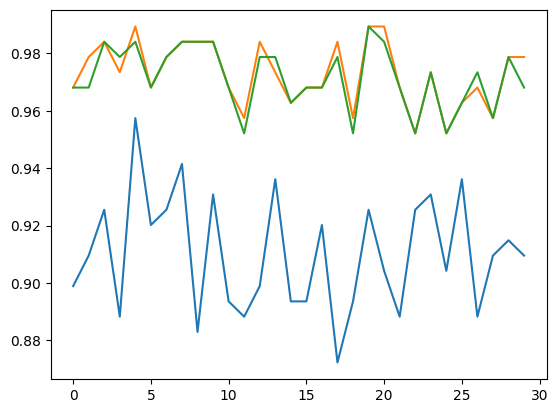

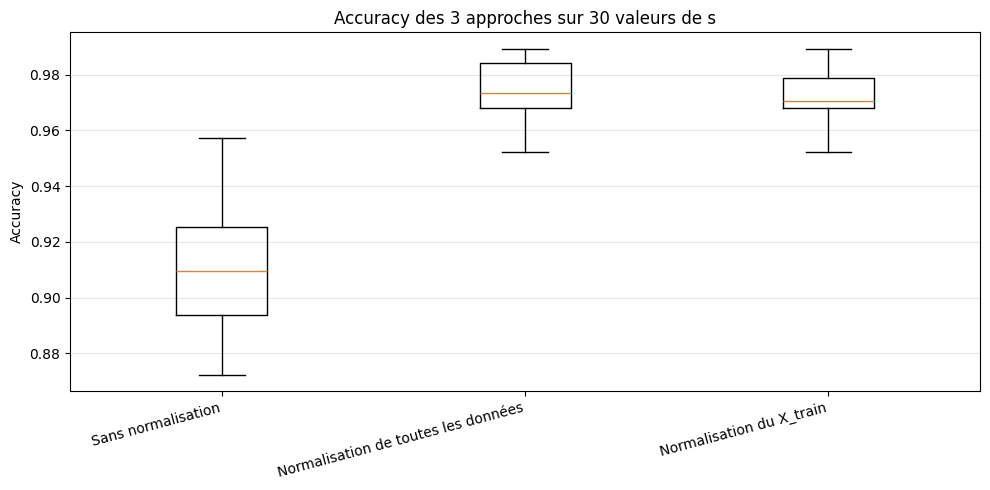


Test de Friedman
Statistique = 53.9604, p-value = 0.000000
Conclusion : on rejette H0, au moins deux approches ont des performances différentes.

Tests de Wilcoxon deux à deux (correction de Bonferroni)
Sans normalisation vs Normalisation de toutes les données : statistique = 0.0000, p-value corrigée = 0.000000 (différence significative)
Sans normalisation vs Normalisation du X_train : statistique = 0.0000, p-value corrigée = 0.000000 (différence significative)
Normalisation de toutes les données vs Normalisation du X_train : statistique = 9.0000, p-value corrigée = 0.083897 (différence non significative)


In [ ]:
import sklearn
from sklearn.datasets import load_breast_cancer
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler

j_breast_cancer = load_breast_cancer()

def execute_test(s: int): 
    X_breast_cancer, y_breast_cancer = j_breast_cancer.data, j_breast_cancer.target

    X_train, X_test, y_train, y_test = train_test_split(X_breast_cancer, y_breast_cancer, test_size=0.33, random_state=s)

    svm = SVC()
    svm.fit(X_train, y_train)
    y_pred = svm.predict(X_test)
    res1 = accuracy_score(y_test,y_pred)
    print(f"Accuracy (s={s}) sans normalisation : %.2f%%" % (res1 * 100.0))


    scaler = MinMaxScaler()

    X_scaled = scaler.fit_transform(X_breast_cancer)
    X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(X_scaled, y_breast_cancer, test_size=0.33, random_state=s)
    svm.fit(X_train_scaled, y_train)
    y_pred = svm.predict(X_test_scaled)
    res2 = accuracy_score(y_test,y_pred)
    print(f"Accuracy (s={s}) avec normalisation de toutes les données: {res2 }")

    X_train_scaled = scaler.fit_transform(X_train)
    svm.fit(X_train_scaled, y_train)
    X_test_scaled = scaler.transform(X_test)
    y_pred = svm.predict(X_test_scaled)
    res3 = accuracy_score(y_test,y_pred)
    print(f"Accuracy (s={s}) avec normalisation du X_train: {res3 }")
    
    return res1, res2, res3

results = []
counter = 0
for s in range(1, 31):
    res1, res2, res3 = execute_test(s)
    results.append([res1, res2, res3])
    if (res2 > res3) :
        counter += 1
    elif (res3 > res2): 
        counter -= 1

if counter > 0:
    print(f"La normalisation de toutes les données est meilleure que celle du X_train")
else:
    print(f"La normalisation du X_train est meilleure que celle de toutes les données")

import matplotlib.pyplot as plt

plt.plot(results)
plt.show()

plt.figure(figsize=(10, 5))
plt.boxplot(
    list(zip(*results)),
    tick_labels=["Sans normalisation", "Normalisation de toutes les données", "Normalisation du X_train"]
)
plt.ylabel("Accuracy")
plt.title("Accuracy des 3 approches sur 30 valeurs de s")
plt.xticks(rotation=15, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

import numpy as np
from scipy.stats import friedmanchisquare, wilcoxon

method_names = [
    "Sans normalisation",
    "Normalisation de toutes les données",
    "Normalisation du X_train"
]
scores = np.asarray(results, dtype=float).T
alpha = 0.05

# Test global de Friedman : les performances des trois approches sont-elles différentes ?
friedman_stat, friedman_p = friedmanchisquare(*scores)
print("\nTest de Friedman")
print(f"Statistique = {friedman_stat:.4f}, p-value = {friedman_p:.6f}")
if friedman_p < alpha:
    print("Conclusion : on rejette H0, au moins deux approches ont des performances différentes.")
else:
    print("Conclusion : on ne rejette pas H0, aucune différence globale significative n'est détectée.")

# Tests de Wilcoxon deux à deux, avec correction de Bonferroni.
n_comparisons = len(method_names) * (len(method_names) - 1) // 2
print("\nTests de Wilcoxon deux à deux (correction de Bonferroni)")
for i in range(len(method_names)):
    for j in range(i + 1, len(method_names)):
        wilcoxon_stat, wilcoxon_p = wilcoxon(
            scores[i], scores[j], alternative="two-sided", method="auto"
        )
        corrected_p = min(wilcoxon_p * n_comparisons, 1.0)
        conclusion = "différence significative" if corrected_p < alpha else "différence non significative"
        print(
            f"{method_names[i]} vs {method_names[j]} : "
            f"statistique = {wilcoxon_stat:.4f}, p-value corrigée = {corrected_p:.6f} "
            f"({conclusion})"
        )

